# Notebook 01 — EDA, Cleaning & Preprocessing

**Project:** XGBoost vs Random Forest — Employee Attrition Prediction  
**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Goal:** Explore the dataset, clean it, handle class imbalance, encode features, and save processed data for model notebooks.

---
### Notebook outline
1. Import libraries
2. Load data & initial inspection
3. Statistical summary
4. EDA — Target distribution
5. EDA — Numerical feature distributions
6. EDA — Categorical feature distributions
7. EDA — Correlation heatmap
8. EDA — Key relationships with Attrition
9. Outlier detection
10. Data cleaning
11. Encoding categorical variables
12. Handle class imbalance (SMOTE)
13. Feature scaling
14. Train/test split
15. Save processed data

### Import Libraries, Load Data & Initial Inspection

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Set style for professional plots
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All libraries imported successfully.")

# Load data (try tab delimiter)
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv', delimiter='\t')

print(f"Dataset loaded successfully!")

All libraries imported successfully.
Dataset loaded successfully!


In [45]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (1470, 35)

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction Standard

In [46]:
# Column data types
print("Data types:")
print(df.dtypes)
print(f"\nNumerical columns : {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include='object').shape[1]}")

Data types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWor

In [47]:
# Missing values check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

Missing values per column:
No missing values found!


In [48]:
# Duplicate rows check
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

Duplicate rows: 0


### Statistical Summary

In [49]:
# Summary statistics for numerical columns
df.describe().T.style.background_gradient(cmap='Blues')


,count,mean,std,min,25%,50%,75%,max
Age,1470.000000,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1470.000000,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1470.000000,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1470.000000,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1470.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1470.000000,1024.865306,602.024335,1.000000,491.250000,1020.500000,1555.750000,2068.000000
EnvironmentSatisfaction,1470.000000,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1470.000000,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1470.000000,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1470.000000,2.063946,1.106940,1.000000,1.000000,2.000000,3.000000,5.000000


In [50]:
# Summary for categorical columns
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [51]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


### EDA — Target Distribution (Attrition)

Understanding class imbalance before modeling is critical. A large imbalance means a naive model can score high accuracy by always predicting the majority class.

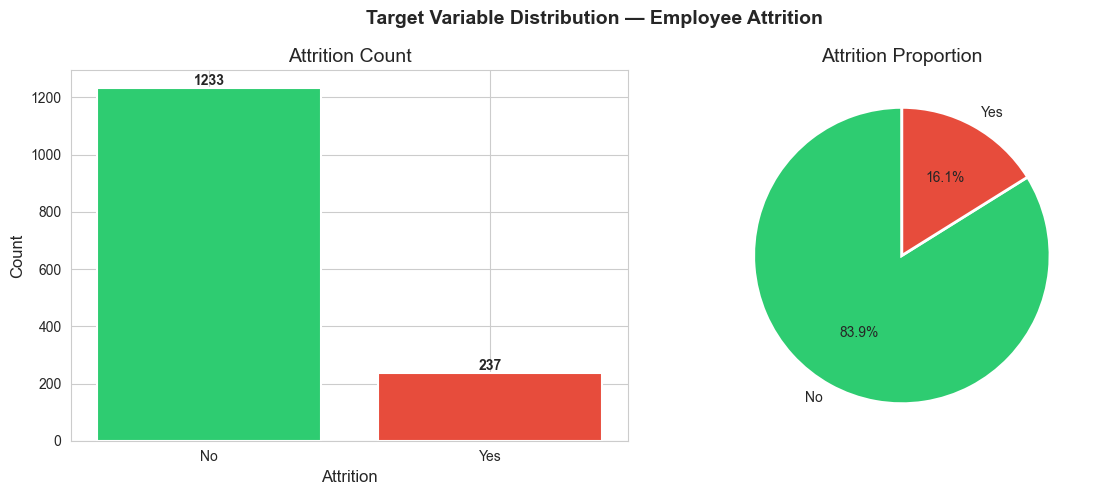


Class distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Imbalance ratio — No:Yes = 5.2:1


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Attrition Proportion')

plt.suptitle('Target Variable Distribution — Employee Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass distribution:")
print(counts)
print(f"\nImbalance ratio — No:Yes = {counts['No']/counts['Yes']:.1f}:1")

### EDA - Numerical Feature Distribution

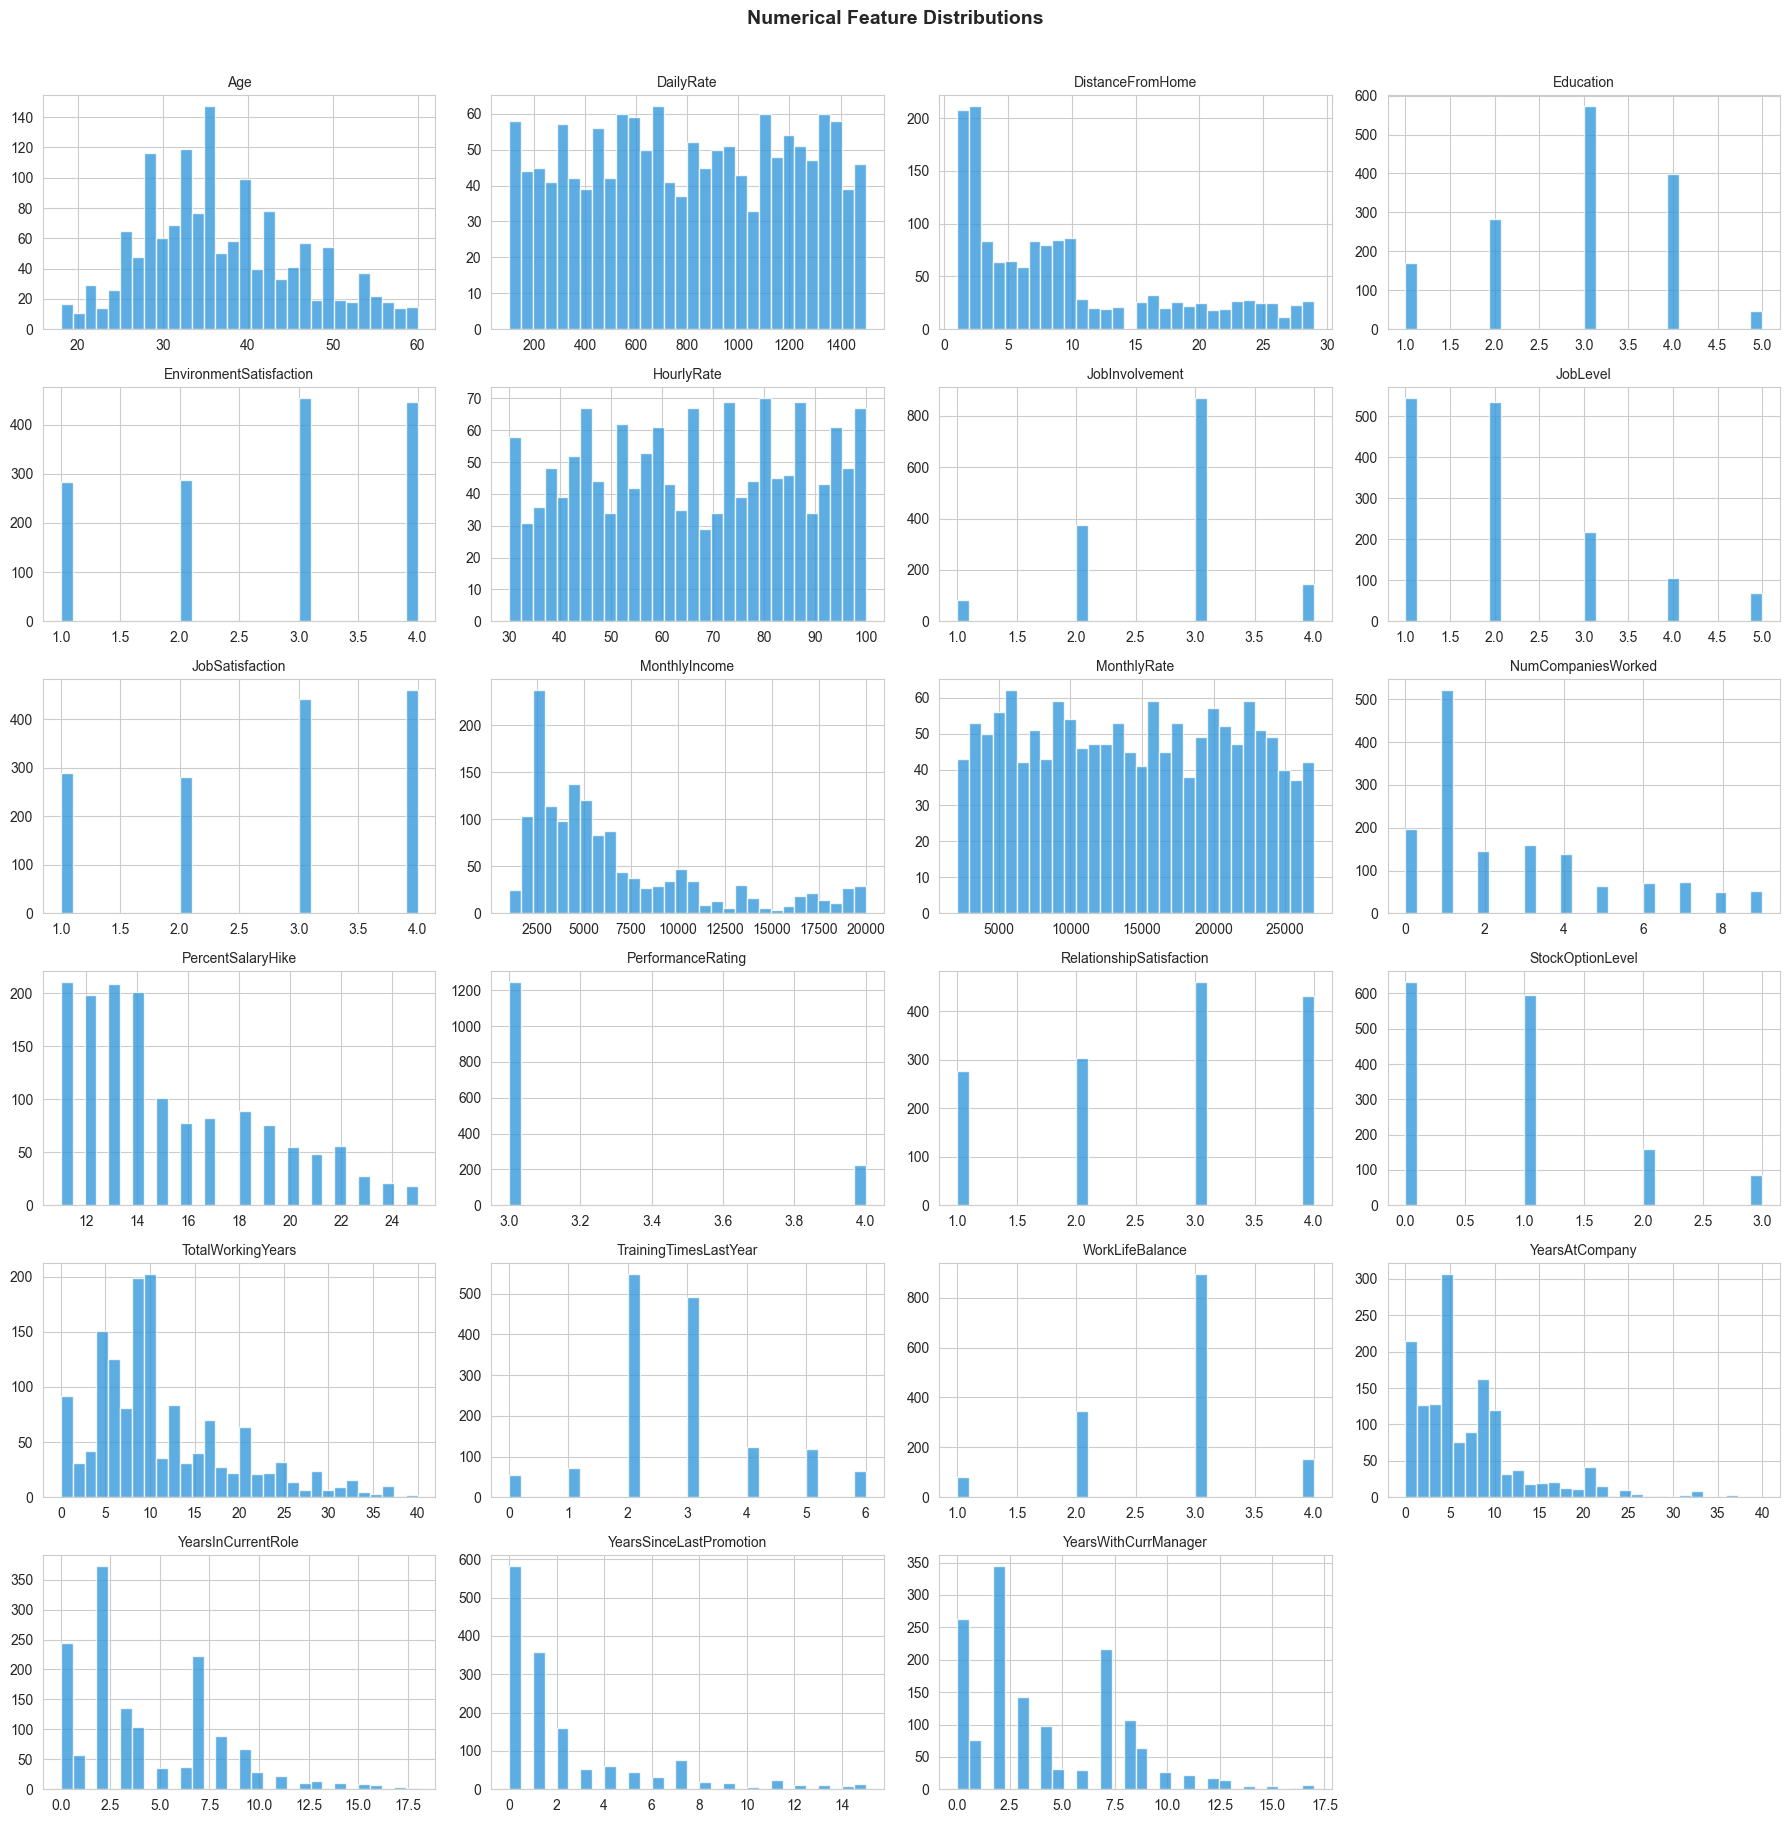

In [53]:
# Distribution of all numerical features
num_cols = df.select_dtypes(include='number').columns.tolist()
# Remove zero-variance columns we'll drop later
num_cols = [c for c in num_cols if c not in ['EmployeeCount', 'StandardHours', 'EmployeeNumber']]

n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

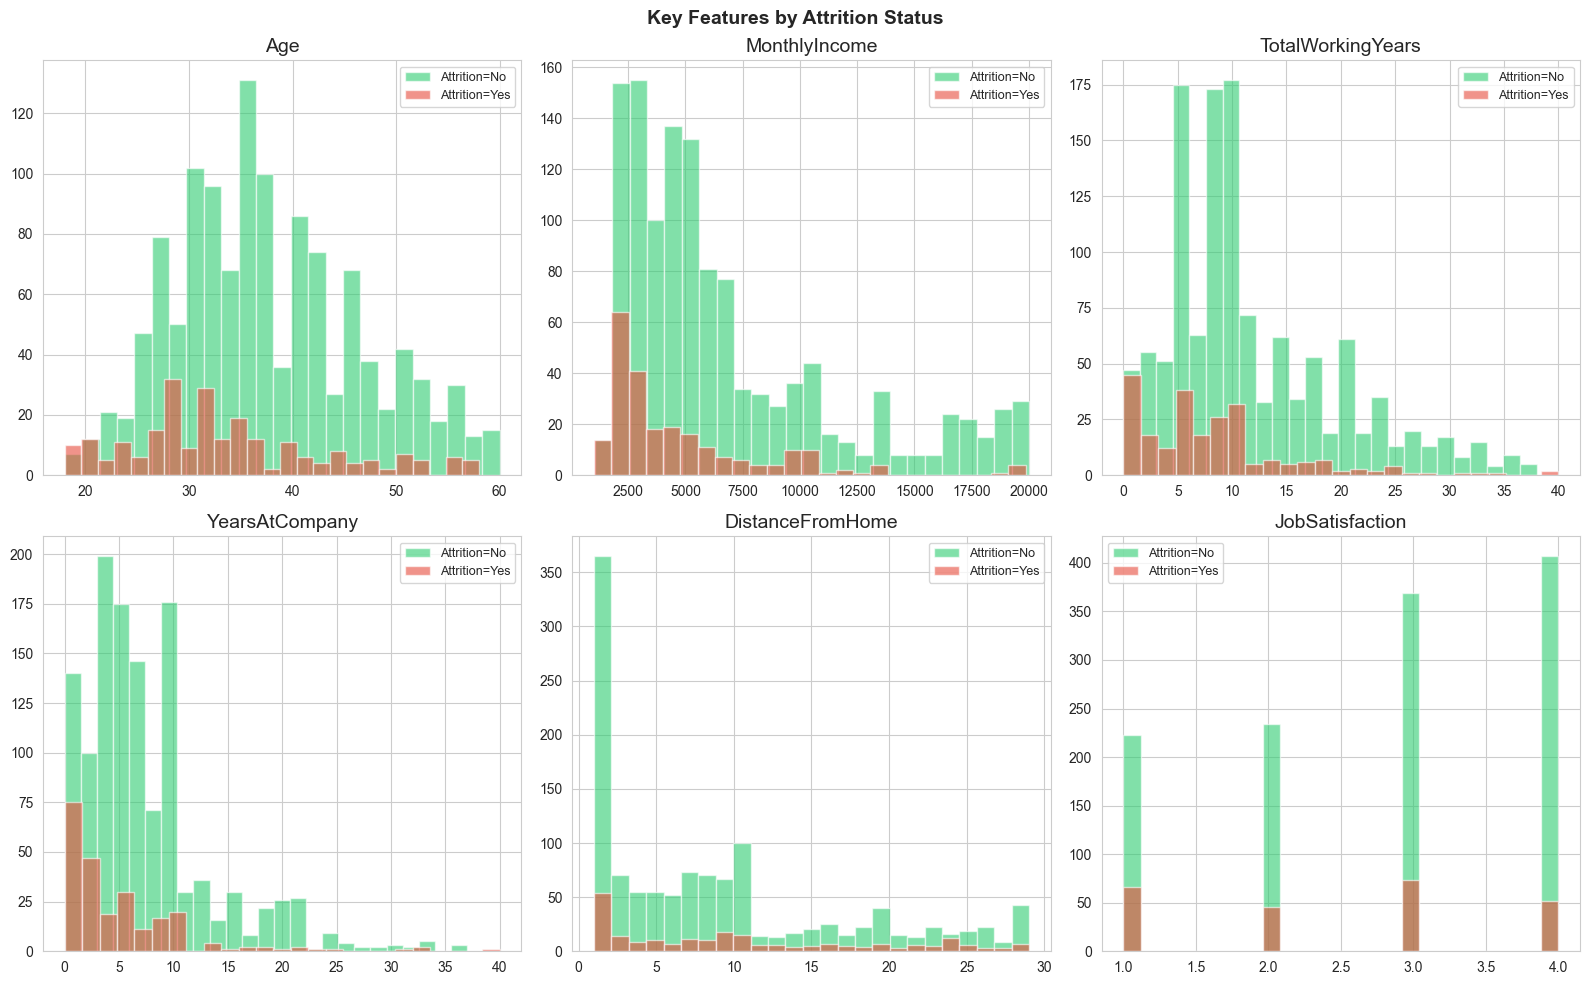

In [54]:
# Key numerical features split by Attrition (Yes vs No)
key_num_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
                    'YearsAtCompany', 'DistanceFromHome', 'JobSatisfaction']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_num_features):
    for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        axes[i].hist(df[df['Attrition'] == label][col], bins=25,
                     alpha=0.6, color=color, label=f'Attrition={label}', edgecolor='white')
    axes[i].set_title(col)
    axes[i].legend(fontsize=9)

plt.suptitle('Key Features by Attrition Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03_key_features_by_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

### EDA - Categorical Feature Distribution

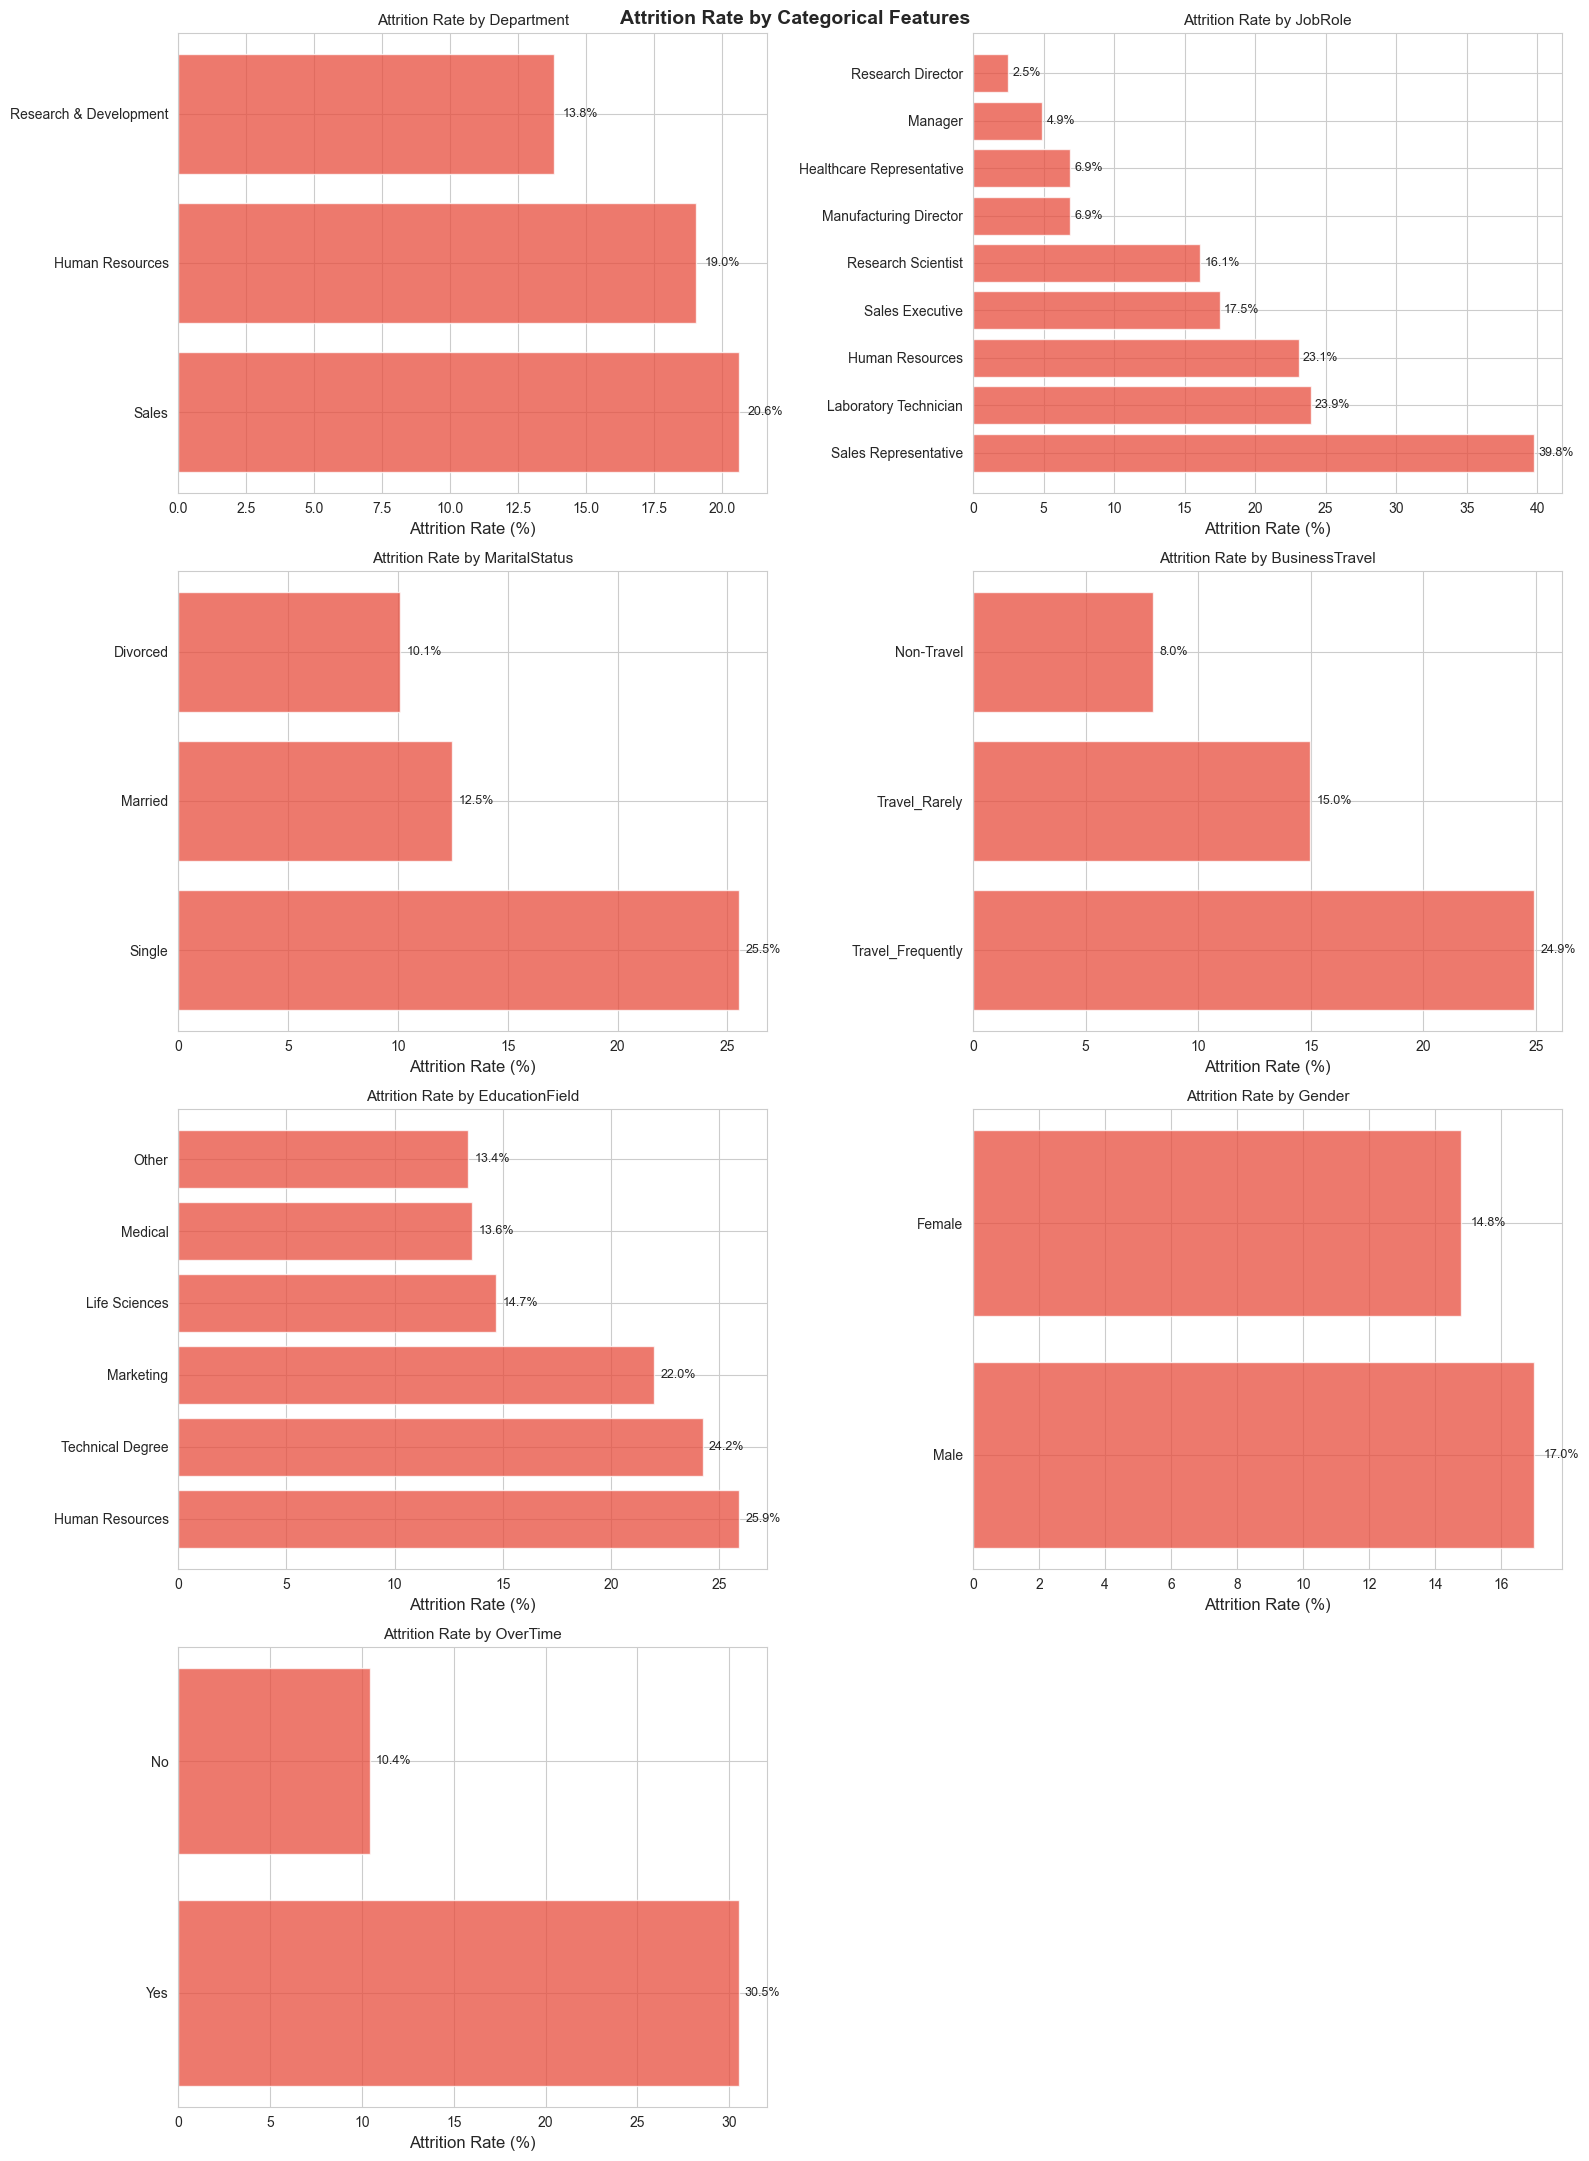

In [55]:
# Attrition rate by each categorical feature
cat_cols = ['Department', 'JobRole', 'MaritalStatus',
            'BusinessTravel', 'EducationField', 'Gender', 'OverTime']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    attrition_rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)

    bars = axes[i].barh(attrition_rate.index, attrition_rate.values,
                        color='#e74c3c', alpha=0.75, edgecolor='white')
    axes[i].set_title(f'Attrition Rate by {col}', fontsize=11)
    axes[i].set_xlabel('Attrition Rate (%)')

    for bar, val in zip(bars, attrition_rate.values):
        axes[i].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Attrition Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/04_categorical_attrition_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### EDA — Correlation Heatmap

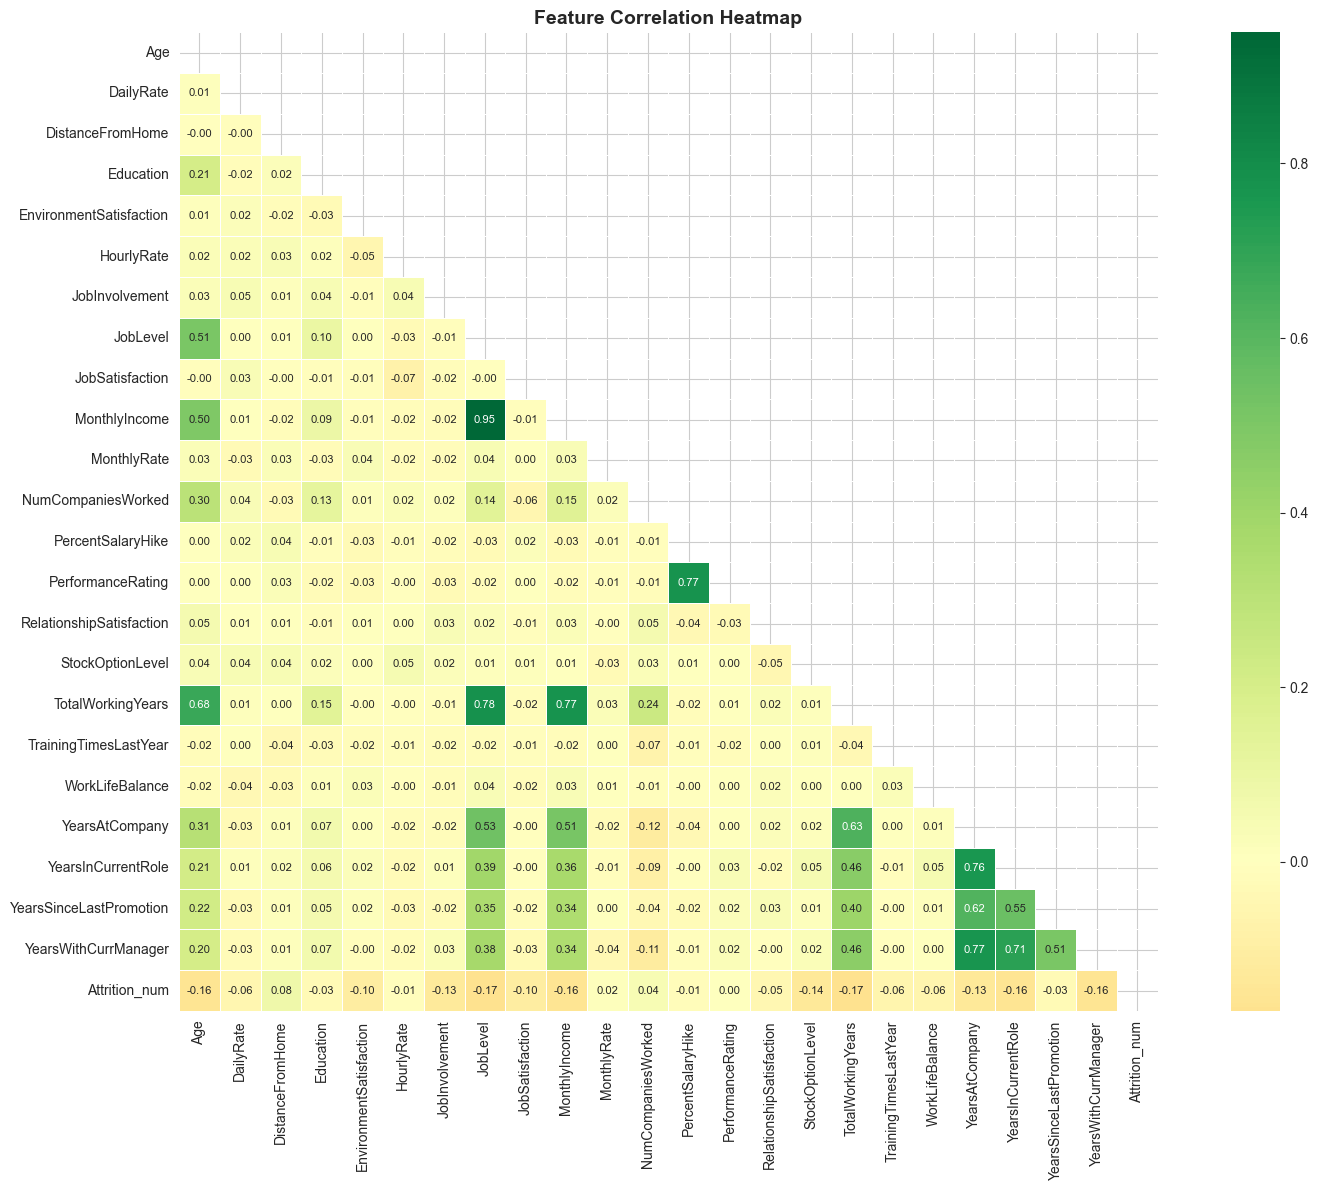

In [56]:
# Encode Attrition temporarily for correlation
df_corr = df.copy()
df_corr['Attrition_num'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})

corr_cols = [c for c in num_cols] + ['Attrition_num']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8}, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# Top features correlated with Attrition
attrition_corr = corr_matrix['Attrition_num'].drop('Attrition_num').sort_values(key=abs, ascending=False)
print("Top 15 features correlated with Attrition:")
print(attrition_corr.head(15).to_string())

Top 15 features correlated with Attrition:
TotalWorkingYears         -0.171063
JobLevel                  -0.169105
YearsInCurrentRole        -0.160545
MonthlyIncome             -0.159840
Age                       -0.159205
YearsWithCurrManager      -0.156199
StockOptionLevel          -0.137145
YearsAtCompany            -0.134392
JobInvolvement            -0.130016
JobSatisfaction           -0.103481
EnvironmentSatisfaction   -0.103369
DistanceFromHome           0.077924
WorkLifeBalance           -0.063939
TrainingTimesLastYear     -0.059478
DailyRate                 -0.056652


### EDA — Key Relationships with Attrition

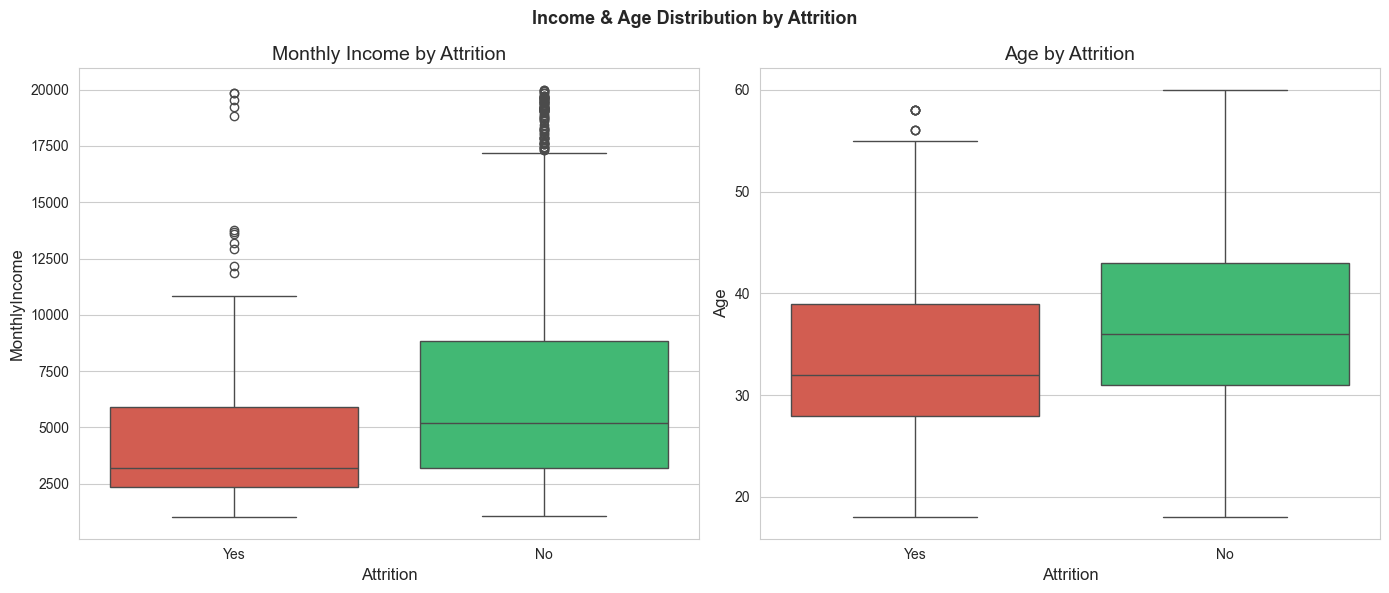

In [58]:
# Box plots — MonthlyIncome and Age by Attrition
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Monthly Income by Attrition')

sns.boxplot(data=df, x='Attrition', y='Age',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Age by Attrition')

plt.suptitle('Income & Age Distribution by Attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/06_boxplots_income_age.png', dpi=150, bbox_inches='tight')
plt.show()

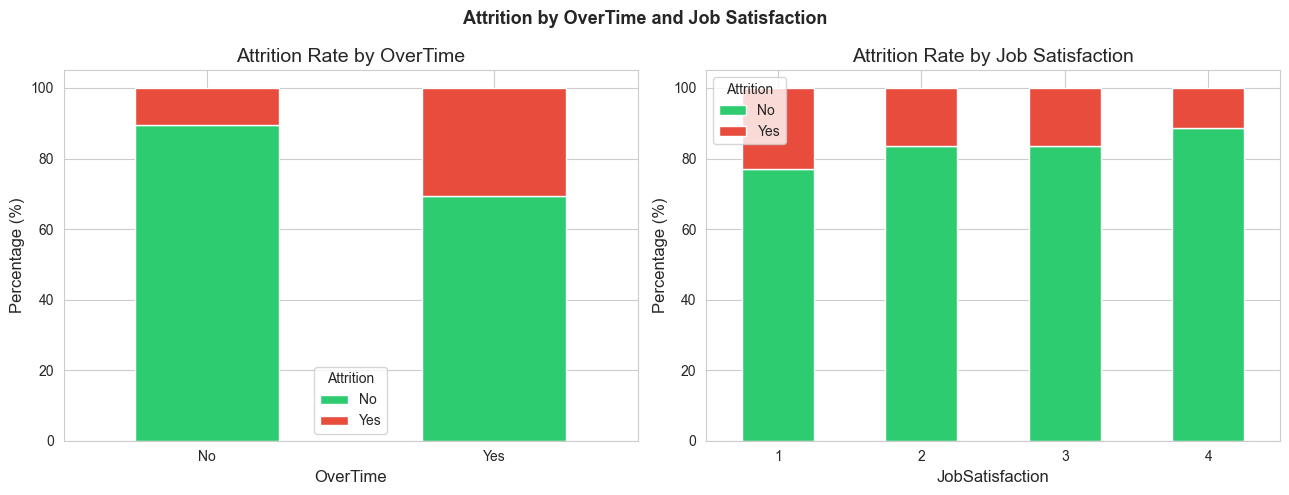

In [59]:
# OverTime vs Attrition — one of the strongest predictors
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar
overtime_attr = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
overtime_attr.plot(kind='bar', stacked=True, ax=axes[0],
                   color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Attrition Rate by OverTime')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Attrition')

# JobSatisfaction vs Attrition
jobsat_attr = pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index') * 100
jobsat_attr.plot(kind='bar', stacked=True, ax=axes[1],
                 color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Attrition Rate by Job Satisfaction')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Attrition')

plt.suptitle('Attrition by OverTime and Job Satisfaction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/07_overtime_jobsat_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

### Outlier Detection

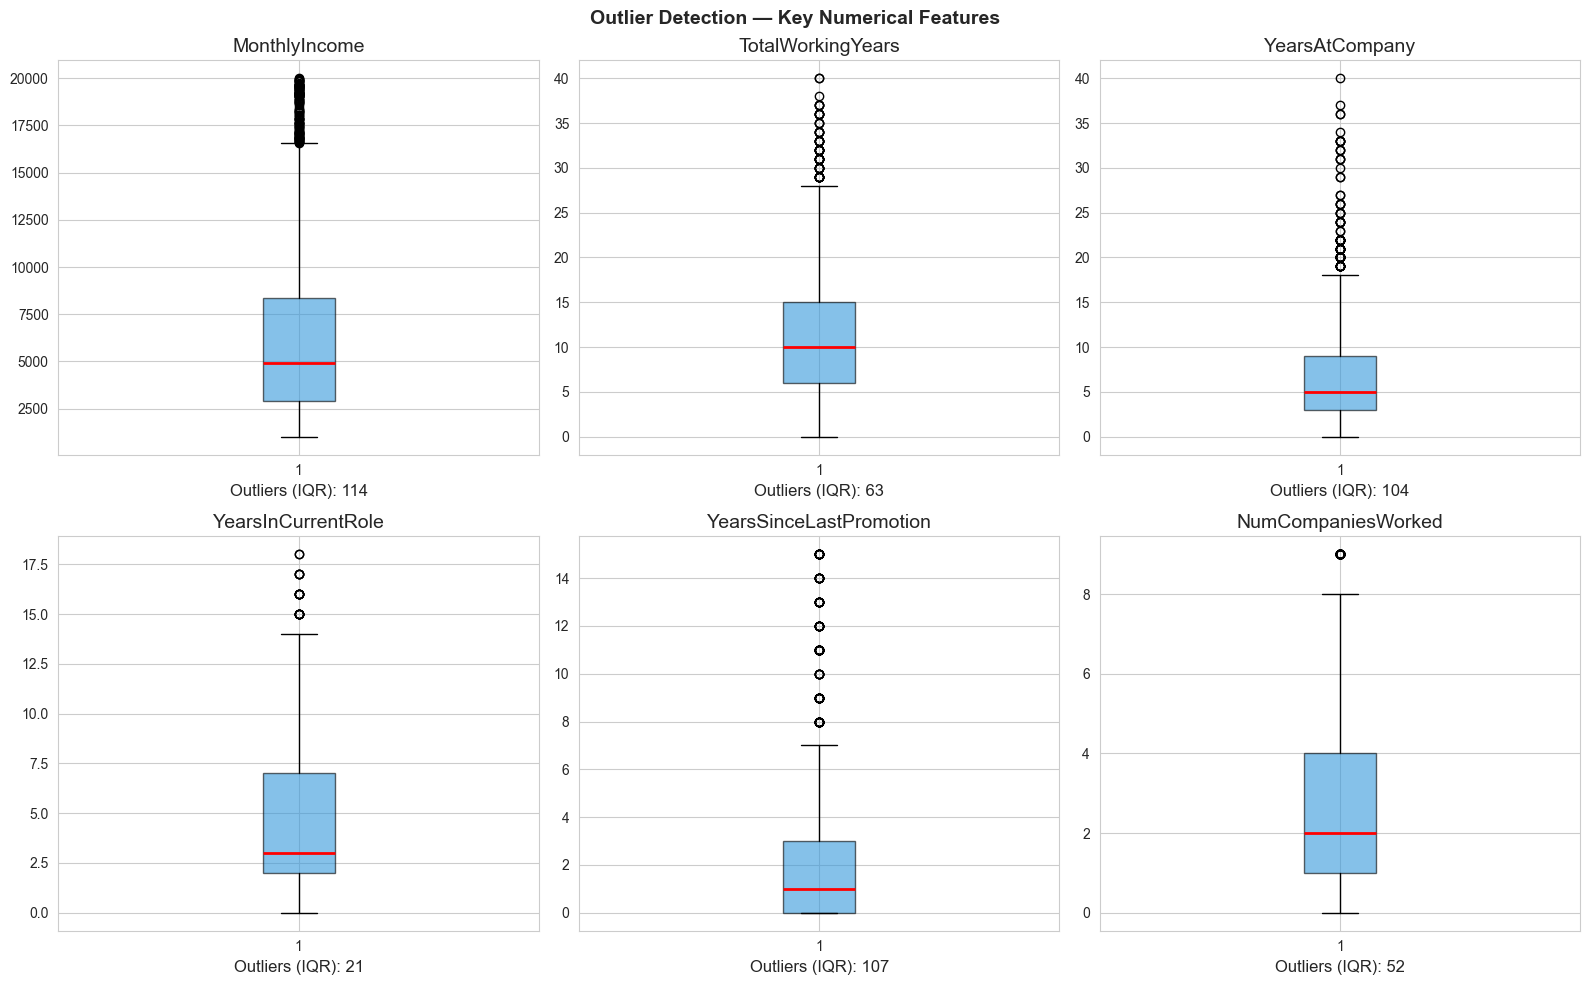

Note: Tree-based models (XGBoost & Random Forest) are robust to outliers.
We will keep outliers since they represent real employee scenarios.


In [60]:
# Box plots to detect outliers in key numerical columns
outlier_cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'YearsInCurrentRole', 'YearsSinceLastPromotion', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)

    # IQR outlier count
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    axes[i].set_xlabel(f'Outliers (IQR): {outliers}')

plt.suptitle('Outlier Detection — Key Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/08_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note: Tree-based models (XGBoost & Random Forest) are robust to outliers.")
print("We will keep outliers since they represent real employee scenarios.")

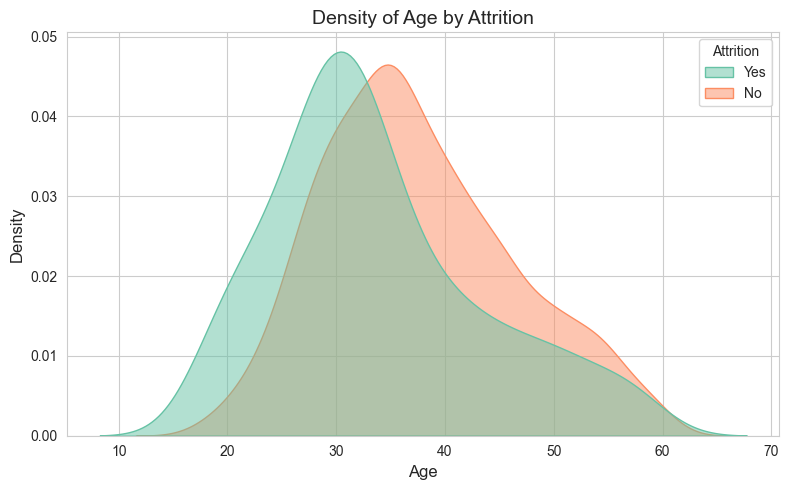

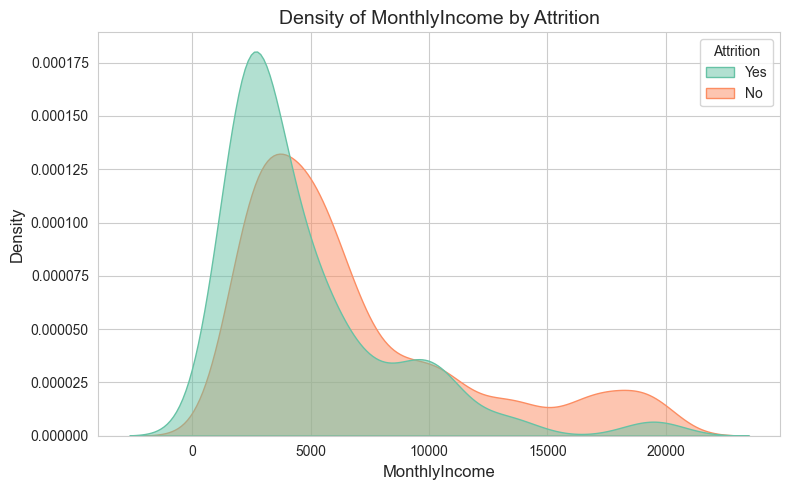

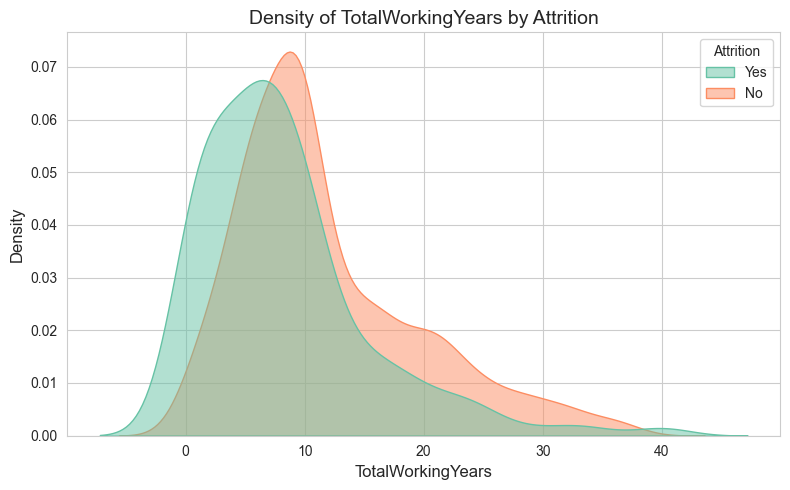

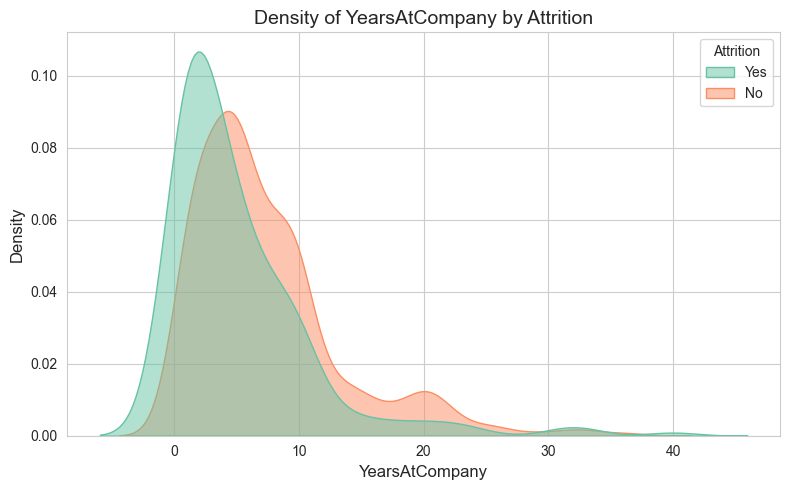

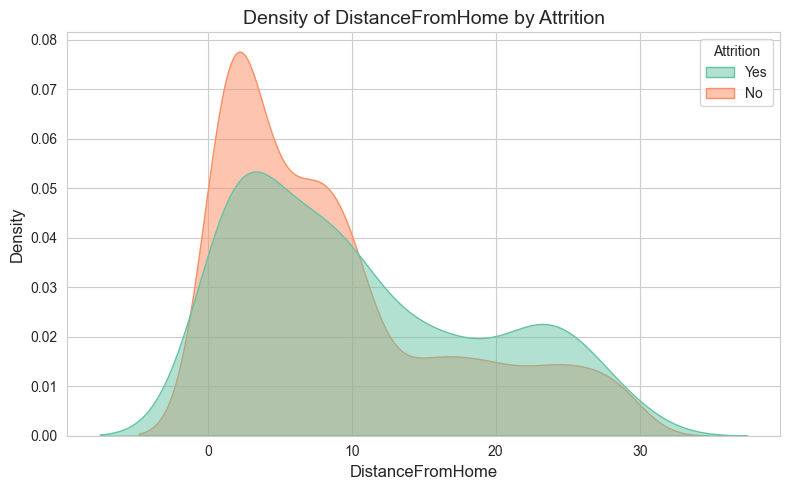

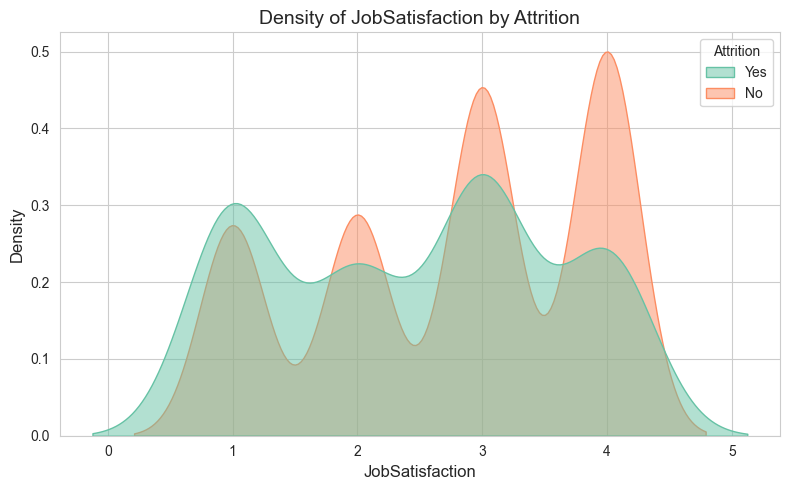

In [61]:
for col in key_num_features:
    plt.figure(figsize=(8,5))
    sns.kdeplot(data=df, x=col, hue='Attrition', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'Density of {col} by Attrition')
    plt.tight_layout()
    plt.savefig('../figures/09_density_of_age_by_attrition.png', dpi=150, bbox_inches='tight')
    plt.show()

## Data Cleaning

Steps:
- Remove duplicate rows
- Drop zero-variance and identifier columns
- Encode the target variable

In [62]:
df_clean = df.copy()

# Remove duplicates
before = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
print(f"Removed {before - df_clean.shape[0]} duplicate rows.")

# Drop zero-variance and ID columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean.drop(cols_to_drop, axis=1, inplace=True)
print(f"Dropped columns: {cols_to_drop}")

# Encode target variable
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print(f"\nTarget encoded: Yes=1, No=0")
print(f"Clean dataset shape: {df_clean.shape}")

Removed 0 duplicate rows.
Dropped columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

Target encoded: Yes=1, No=0
Clean dataset shape: (1470, 31)


### Encoding Categorical Variables

- Binary columns (`Gender`, `OverTime`): Label encoding
- Nominal columns (`Department`, `JobRole`, etc.): One-hot encoding

In [63]:
# Binary label encoding
binary_map = {
    'Gender': {'Male': 1, 'Female': 0},
    'OverTime': {'Yes': 1, 'No': 0}
}
for col, mapping in binary_map.items():
    df_clean[col] = df_clean[col].map(mapping)

# One-hot encoding for nominal categorical columns
nominal_cols = ['BusinessTravel', 'Department', 'EducationField',
                'JobRole', 'MaritalStatus']
df_clean = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)

print(f"Shape after encoding: {df_clean.shape}")
print(f"\nAll columns:")
print(list(df_clean.columns))

Shape after encoding: (1470, 45)

All columns:
['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobR

In [64]:
# Separate features and target
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

print(f"Features shape: {X.shape}")
print(f"Target shape  : {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features shape: (1470, 44)
Target shape  : (1470,)

Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


### Handle Class Imbalance — SMOTE

The dataset has an imbalance (No:Yes). We apply **SMOTE** (Synthetic Minority Over-sampling Technique) to generate synthetic samples for the minority class.

>  SMOTE is applied **only on training data** after the train/test split to prevent data leakage.

In [65]:
# Train/test split FIRST, then apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── SAVE ORIGINAL UNBALANCED SPLITS HERE (before SMOTE) ──────────────────────
# These are needed by Notebook 02 for leakage-free cross-validation
X_train.to_csv(os.path.join('../data/processed', 'X_train_orig.csv'), index=False)
y_train.to_csv(os.path.join('../data/processed', 'y_train_orig.csv'), index=False)
print("Original unbalanced splits saved.")
# ─────────────────────────────────────────────────────────────────────────────

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"\nTraining class distribution (before SMOTE):")
print(y_train.value_counts())

Original unbalanced splits saved.
Training set  : 1176 samples
Test set      : 294 samples

Training class distribution (before SMOTE):
Attrition
0    986
1    190
Name: count, dtype: int64


Training class distribution (after SMOTE):
Attrition
0    986
1    986
Name: count, dtype: int64


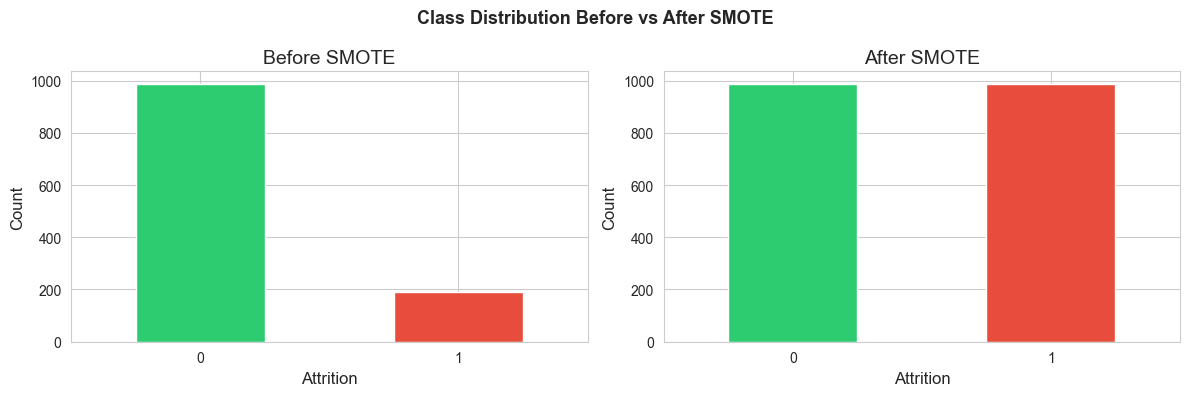

In [66]:
# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Training class distribution (after SMOTE):")
print(pd.Series(y_train_smote).value_counts())

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                             edgecolor='white', rot=0)
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=axes[1],
                                              color=['#2ecc71', '#e74c3c'],
                                              edgecolor='white', rot=0)
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/10_smote_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Scaling

StandardScaler is applied for completeness. Note: XGBoost and Random Forest are tree-based models and do **not** require scaling — but scaling is useful for any future comparison with logistic regression or SVM.

In [67]:
scaler = StandardScaler()

# Fit only on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"X_train (scaled) shape: {X_train_scaled.shape}")
print(f"X_test  (scaled) shape: {X_test_scaled.shape}")

X_train (scaled) shape: (1972, 44)
X_test  (scaled) shape: (294, 44)


### Save Processed Data

Saving all splits so model notebooks (02 and 03) can load them directly without repeating preprocessing.

In [68]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save cleaned (encoded, not scaled) full dataset
df_clean.to_csv(os.path.join(PROCESSED_DIR, 'cleaned_dataset.csv'), index=False)

# Save train/test splits (unscaled — for tree models)
X_train_smote.to_csv(os.path.join(PROCESSED_DIR, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(PROCESSED_DIR, 'X_test.csv'), index=False)
pd.Series(y_train_smote, name='Attrition').to_csv(os.path.join(PROCESSED_DIR, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(PROCESSED_DIR, 'y_test.csv'), index=False)

# Save scaled splits (for any future linear models)
X_train_scaled.to_csv(os.path.join(PROCESSED_DIR, 'X_train_scaled.csv'), index=False)
X_test_scaled.to_csv(os.path.join(PROCESSED_DIR, 'X_test_scaled.csv'), index=False)

print("All processed files saved to data/processed/:")
for f in os.listdir(PROCESSED_DIR):
    size = os.path.getsize(os.path.join(PROCESSED_DIR, f))
    print(f"  {f:35s} {size/1024:.1f} KB")

All processed files saved to data/processed/:
  cleaned_dataset.csv                 253.5 KB
  X_test.csv                          50.8 KB
  X_test_scaled.csv                   251.1 KB
  X_train.csv                         337.5 KB
  X_train_orig.csv                    200.7 KB
  X_train_scaled.csv                  1685.6 KB
  y_test.csv                          0.9 KB
  y_train.csv                         5.8 KB
  y_train_orig.csv                    3.5 KB


In [70]:
# Final summary
print("=" * 50)
print("PREPROCESSING COMPLETE — SUMMARY")
print("=" * 50)
print(f"Original dataset shape  : {df.shape}")
print(f"Cleaned dataset shape   : {df_clean.shape}")
print(f"Features used           : {X.shape[1]}")
print(f"Training samples (SMOTE): {X_train_smote.shape[0]}")
print(f"Test samples            : {X_test.shape[0]}")
print(f"Figures saved to        : figures/")
print(f"Processed data saved to : data/processed/")

PREPROCESSING COMPLETE — SUMMARY
Original dataset shape  : (1470, 35)
Cleaned dataset shape   : (1470, 45)
Features used           : 44
Training samples (SMOTE): 1972
Test samples            : 294
Figures saved to        : figures/
Processed data saved to : data/processed/
